In [25]:
import numpy as np
import matplotlib.pyplot as plt 
import seaborn as sns 
import pandas as pd 

In [26]:
df=pd.read_csv('C:\\Users\\LoQ\\Desktop\\78_row\\dimension78row.csv')
df1=df.drop(columns=['Normal',
       'MildModerateDilation', 'VSD', 'ASD', 'DORV', 'DLoopTGA',
       'ArterialSwitch', 'BilateralSVC', 'SevereDilation', 'TortuousVessels',
       'Dextrocardia', 'Mesocardia', 'InvertedVentricles', 'InvertedAtria',
       'LeftCentralIVC', 'LeftCentralSVC', 'LLoopTGA', 'AtrialSwitch',
       'Rastelli', 'SingleVentricle', 'DILV', 'DIDORV', 'CommonAtrium',
       'Glenn', 'Fontan', 'Heterotaxy', 'SuperoinferiorVentricles',
       'PAAtresiaOrMPAStump', 'PABanding', 'AOPAAnastamosis', 'Marfan',
       'CMRArtifactAO', 'CMRArtifactPA','patient id'])

In [27]:
(df1['age '].unique()).size

41

In [28]:
df1['class '].value_counts()

class 
2    36
0    32
1    11
Name: count, dtype: int64

In [29]:
df1.columns

Index(['age ', 'class ', 'x', 'y', 'z'], dtype='object')

In [30]:
df1.describe()

,age,class,x,y,z
count,79.000000,79.000000,79.000000,79.000000,79.000000
mean,21.000000,1.050633,85.337764,112.971941,73.335734
std,19.937724,0.932308,25.509570,25.433678,22.485768
min,0.000000,0.000000,33.490000,55.900000,35.270000
25%,3.000000,0.000000,66.705000,103.366667,55.440000
50%,15.000000,1.000000,85.360000,112.600000,75.110000
75%,38.000000,2.000000,100.750000,124.250000,89.918333
max,67.000000,2.000000,160.000000,176.100000,130.360000


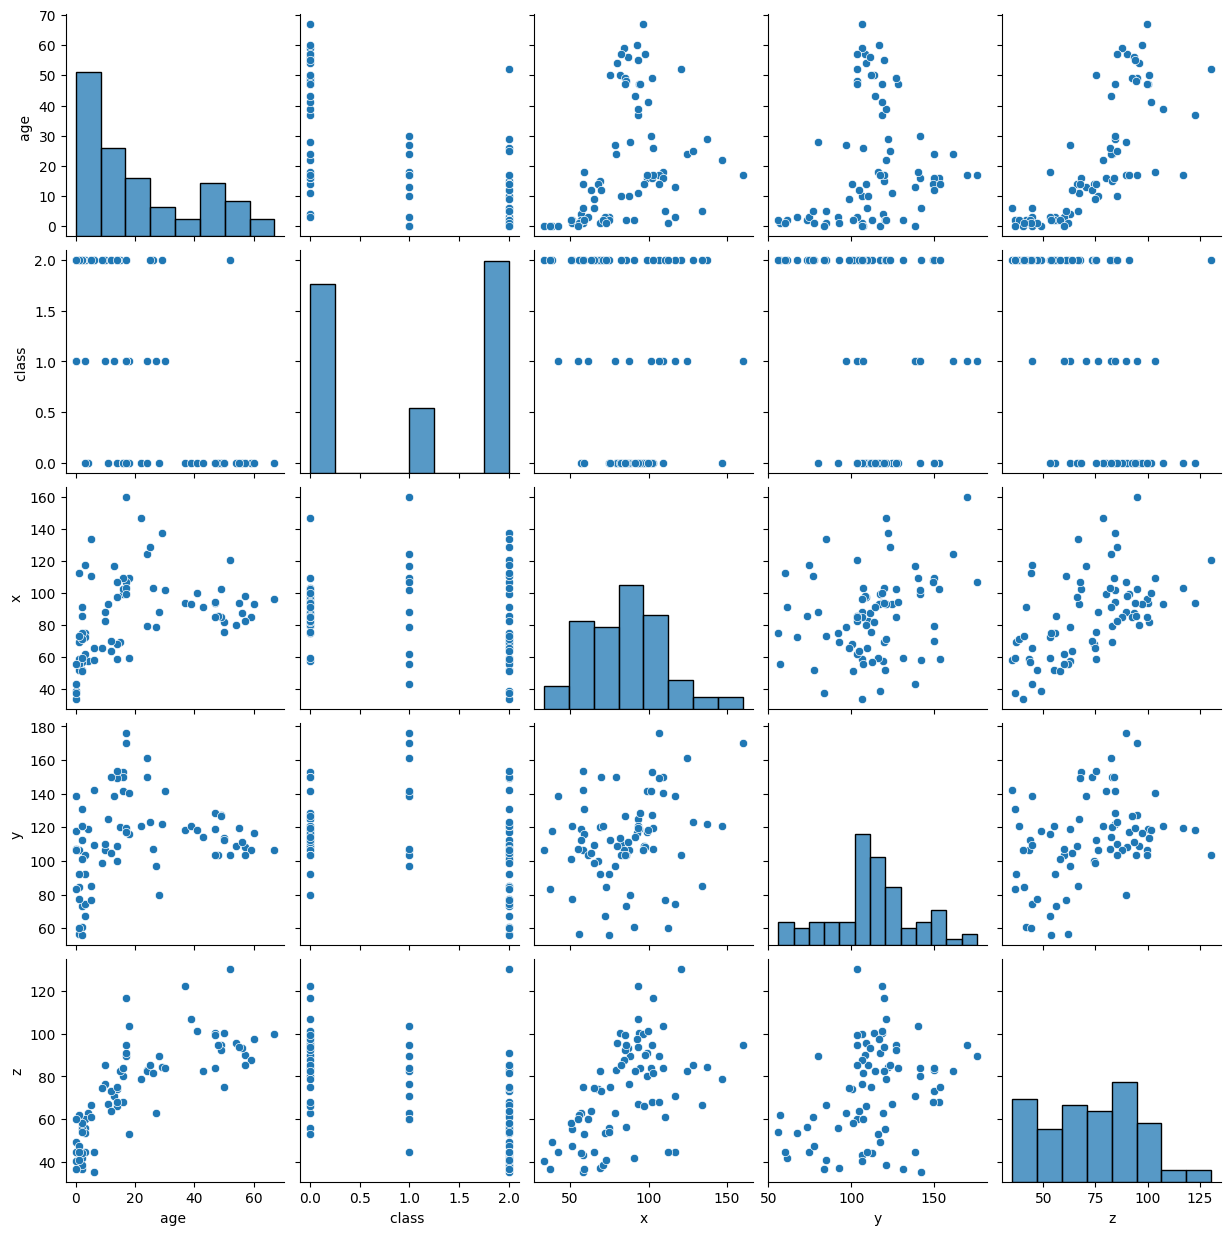

In [33]:
sns.pairplot(df1)

In [34]:
from scipy.stats import skew

print("Skewness:", skew(df1))

Skewness: [ 0.7268308  -0.10044461  0.35058317 -0.05151737  0.09777065]


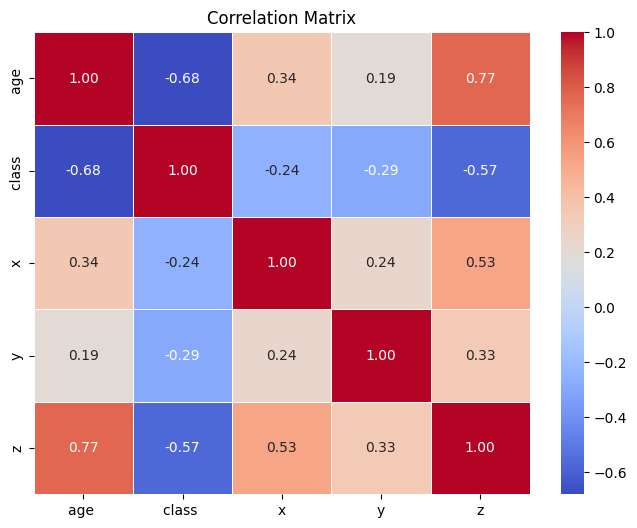

In [35]:
correlation_matrix =df1.corr()

# رسم خريطة الارتباط باستخدام Seaborn
plt.figure(figsize=(8, 6))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt=".2f", linewidths=0.5)
plt.title("Correlation Matrix")
plt.show()

In [36]:

df1['y*z']=(df1['z']*df1['y'])
df1['x*z']=df1['x']*df1['z']
# df1['x+y']=df1['x']+df1['y']



c:\Users\LoQ\AppData\Local\Programs\Python\Python312\Lib\site-packages\pandas\core\internals\blocks.py:393: RuntimeWarning: divide by zero encountered in log10
  result = func(self.values, **kwargs)


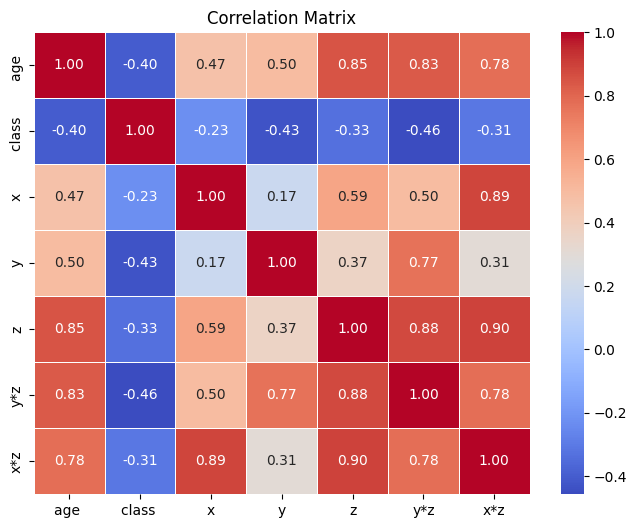

In [38]:
correlation_matrix =np.log10(df1).corr()

# رسم خريطة الارتباط باستخدام Seaborn
plt.figure(figsize=(8, 6))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt=".2f", linewidths=0.5)
plt.title("Correlation Matrix")
plt.show()

<Axes: >

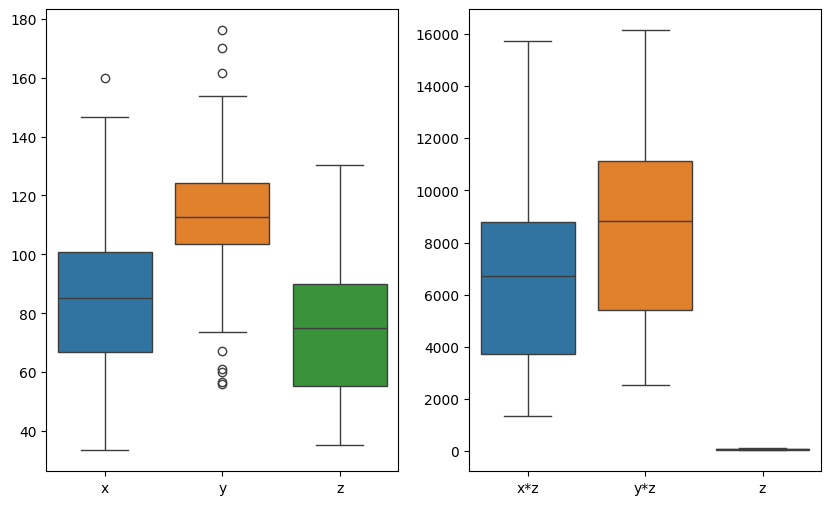

In [39]:
plt.figure(figsize=(10,6))
plt.subplot(1,2,1)
sns.boxplot((df1[['x','y','z']]))
plt.subplot(1,2,2)
sns.boxplot((df1[['x*z','y*z','z']]))

In [40]:
from scipy.stats import skew


print("Skewness:", skew(df1[['x*z','y*z','z']]))

Skewness: [0.39808721 0.06373401 0.09777065]


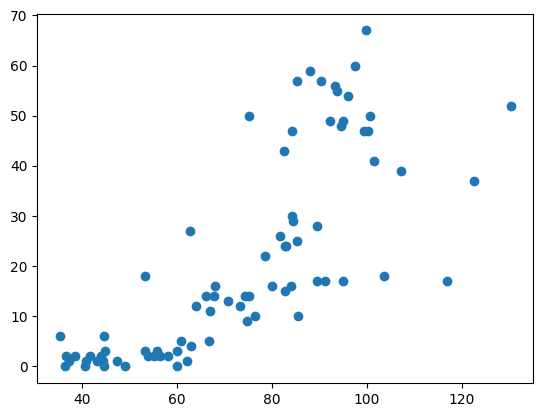

In [41]:
plt.scatter(df1['z'],df1['age '])

In [43]:
class_counts = df['class '].value_counts()

In [44]:
class_counts

class 
2    36
0    32
1    11
Name: count, dtype: int64

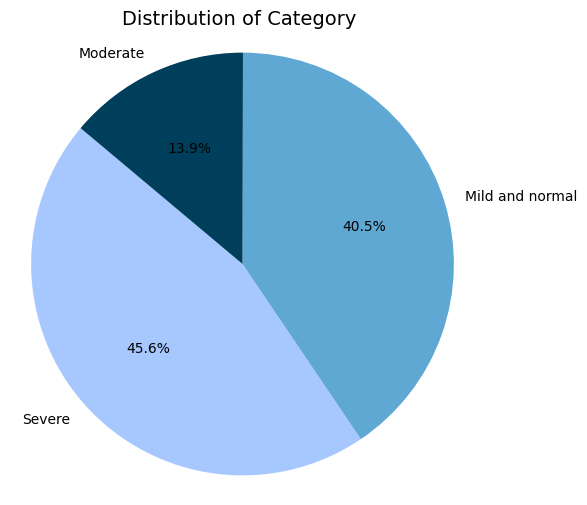

In [45]:

class_counts = df['class '].value_counts()

# Define custom blue-level colors
colors = ['#a6c8ff', '#5fa8d3', '#003f5c']  # light to dark blue

# Plot pie chart
plt.figure(figsize=(6, 6))
plt.pie(class_counts, labels=['Severe','Mild and normal','Moderate'],autopct='%1.1f%%', colors=colors, startangle=140)
plt.title('Distribution of Category ', fontsize=14)
plt.axis('equal')  # Equal aspect ratio ensures the pie is round
plt.show()

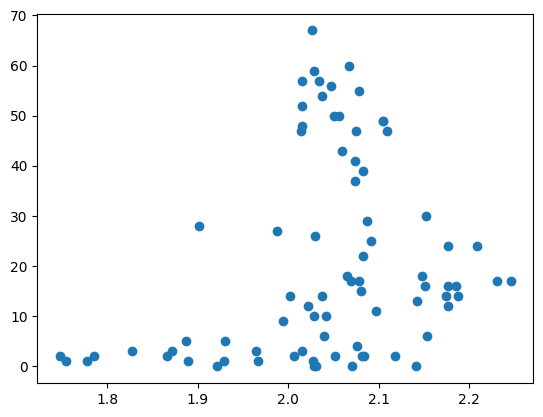

In [46]:
plt.scatter(np.log10(df1['y']),df1['age '])

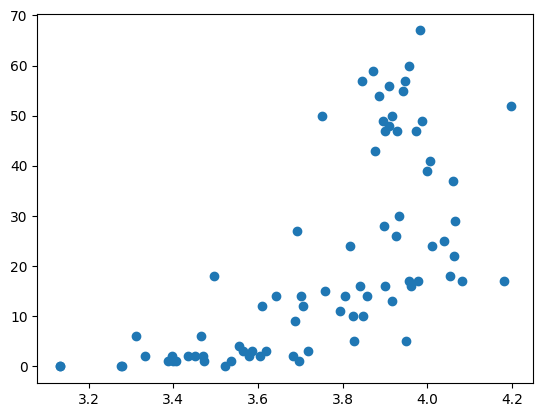

In [47]:
plt.scatter(np.log10(df1['x*z']),df1['age '])

In [48]:
(df1['age ']<12).sum()

np.int64(32)

In [49]:
df1.columns

Index(['age ', 'class ', 'x', 'y', 'z', 'y*z', 'x*z'], dtype='object')

In [50]:
df1.describe()

,age,class,x,y,z,y*z,x*z
count,79.000000,79.000000,79.000000,79.000000,79.000000,79.000000,79.000000
mean,21.000000,1.050633,85.337764,112.971941,73.335734,8473.335726,6558.998645
std,19.937724,0.932308,25.509570,25.433678,22.485768,3503.656113,3248.387104
min,0.000000,0.000000,33.490000,55.900000,35.270000,2544.920000,1356.010100
25%,3.000000,0.000000,66.705000,103.366667,55.440000,5405.190000,3733.582000
50%,15.000000,1.000000,85.360000,112.600000,75.110000,8825.871553,6711.180000
75%,38.000000,2.000000,100.750000,124.250000,89.918333,11116.923666,8803.914978
max,67.000000,2.000000,160.000000,176.100000,130.360000,16137.387000,15729.237600


In [51]:
X=df1[['age ','class ']]
Y=np.log10(df1[['z','y*z', 'x*z']])

from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X,Y , test_size=0.25,random_state=42)



In [52]:
Y.describe()

,z,y*z,x*z
count,79.000000,79.000000,79.000000
mean,1.843300,3.884327,3.754046
std,0.143031,0.206851,0.250304
min,1.547405,3.405674,3.132263
25%,1.743814,3.732284,3.572064
50%,1.875698,3.945758,3.826799
75%,1.953844,4.045961,3.944673
max,2.115144,4.207833,4.196708


In [53]:
from sklearn.preprocessing import PolynomialFeatures
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score
poly_features = PolynomialFeatures(degree=4)
X_train_poly = poly_features.fit_transform(X_train)
X_test_poly = poly_features.transform(X_test)
model1 = LinearRegression()
model1.fit(X_train_poly, y_train)
y_train_predict = model1.predict(X_train_poly)
y_test_predict = model1.predict(X_test_poly)
r2_train = r2_score(y_train, y_train_predict)
r2_test = r2_score(y_test, y_test_predict)
print("r2 on trainset:",r2_train)
print("r2 on testset:",r2_test)

r2 on trainset: 0.7897740492902218
r2 on testset: 0.7134991684723048


In [54]:
c=poly_features.transform([[16,0]])
p=10**model1.predict(c)
print(p[0,0],(p[0,1]/p[0,0]),(p[0,2]/p[0,0]))


75.1910968053028 120.9295589928547 89.94675001090025


c:\Users\LoQ\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\utils\validation.py:2739: UserWarning: X does not have valid feature names, but PolynomialFeatures was fitted with feature names
  warnings.warn(


In [55]:
print(p[0,1])

9092.826176854314


In [56]:
X_test.head(25)

,age,class
30,6,2
0,10,1
22,0,2
31,17,2
18,16,0
28,2,2
10,22,0
70,57,0
4,2,2
12,16,0


In [57]:
X_train_poly[0,:].size

15

In [58]:
from sklearn.neighbors import KNeighborsRegressor
from sklearn.metrics import r2_score 


model3 = KNeighborsRegressor(n_neighbors=8)

model3.fit(X_train, y_train)

preds = model3.predict(X_test)

y_train_pred = model3.predict(X_train)


print("R² train:", r2_score(y_train,y_train_pred))
print("R² test:", r2_score(y_test, preds))

R² train: 0.7405627901951443
R² test: 0.7402730586978556


In [183]:
p=10**model3.predict([[9,2]])
print(p[0,0],(p[0,1]/p[0,0]),(p[0,2]/p[0,0]))


64.50803990817784 108.60010975798099 86.0752780522793


c:\Users\LoQ\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\utils\validation.py:2739: UserWarning: X does not have valid feature names, but KNeighborsRegressor was fitted with feature names
  warnings.warn(


In [80]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.multioutput import MultiOutputRegressor
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, root_mean_squared_error
import numpy as np

# 📌 تعريف النموذج RandomForestRegressor مع MultiOutput
model = MultiOutputRegressor(RandomForestRegressor(bootstrap=True,
    max_depth=2,
    n_estimators=300,
    random_state=42,oob_score=True))
model.fit(X_train, y_train)

# 📌 التنبؤ بالقيم
y_pred = model.predict(X_test)

# 📌 تقييم النموذج باستخدام MSE


mse = mean_squared_error(y_test, y_pred)
print("Mean Squared Error (MSE):", mse)

y_train_predict = model.predict(X_train)

overall_r2 = r2_score(y_test, y_pred)
r2 = r2_score(y_train, y_train_predict)
print("r2 on trainset:",r2)
print("Overall R² Score for the model:", overall_r2)


Mean Squared Error (MSE): 0.01294513114683958
r2 on trainset: 0.7645073656764132
Overall R² Score for the model: 0.7570854858087248


In [187]:
p=10**model.predict([[2,2]])

print((p[0,2]/p[0,0]),(p[0,1]/p[0,0]),p[0,0])

59.635753816212315 93.92973378121168 48.83650534798283


c:\Users\LoQ\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\utils\validation.py:2739: UserWarning: X does not have valid feature names, but RandomForestRegressor was fitted with feature names
  warnings.warn(
c:\Users\LoQ\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\utils\validation.py:2739: UserWarning: X does not have valid feature names, but RandomForestRegressor was fitted with feature names
  warnings.warn(
c:\Users\LoQ\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\utils\validation.py:2739: UserWarning: X does not have valid feature names, but RandomForestRegressor was fitted with feature names
  warnings.warn(


In [188]:
# knn
p=10**model3.predict([[2,2]])
print((p[0,2]/p[0,0]),(p[0,1]/p[0,0]),p[0,0])

59.34487879752257 88.58434739076975 48.71295157704991


c:\Users\LoQ\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\utils\validation.py:2739: UserWarning: X does not have valid feature names, but KNeighborsRegressor was fitted with feature names
  warnings.warn(


In [190]:
c=poly_features.transform([[2,2]])
p=10**model1.predict(c)
print((p[0,2]/p[0,0]),(p[0,1]/p[0,0]),p[0,0])

61.95423258389935 89.73331837067242 47.914922260253064


c:\Users\LoQ\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\utils\validation.py:2739: UserWarning: X does not have valid feature names, but PolynomialFeatures was fitted with feature names
  warnings.warn(


In [65]:
# for i, estimator in enumerate(model.estimators_):
#     print(f"Target {i+1} OOB R2 score: {estimator.oob_score_}")

In [99]:
from sklearn.metrics import mean_squared_error
import numpy as np

# لكل هدف (target) داخل MultiOutputRegressor
for i, estimator in enumerate(model.estimators_):
    # توقعات الـ OOB samples
    oob_pred = estimator.oob_prediction_
    
    # القيم الحقيقية للـ OOB
    true_values = y_train.iloc[:, i].values  # العمود i من الأهداف
    
    # حساب الـ MSE فقط على العينات التي تحتوي على قيم OOB صالحة
    mask = ~np.isnan(oob_pred)
    mse = mean_squared_error(true_values[mask], oob_pred[mask])
    
    print(f"Target {i+1} OOB MSE: {mse:.4f}")


Target 1 OOB MSE: 0.0056
Target 2 OOB MSE: 0.0119
Target 3 OOB MSE: 0.0210


In [237]:
y_pred =10**model.predict(X_test)
y_tes=10**y_test

In [238]:
y_tes['y']=y_tes['y*z']/ y_tes['z']
y_tes['x']=y_tes['x*z']/ y_tes['z']

In [239]:
new_col = np.array(y_pred[:,1])

# Add new column
result = np.column_stack((y_pred, new_col))

In [240]:
new_col = np.array(y_pred[:,1]/y_tes['z'])

# Add new column
result = np.column_stack((y_pred, new_col))

In [241]:
new_col1 = np.array(y_pred[:,2]/y_tes['z'])

# Add new column
result1 = np.column_stack((result, new_col1))

In [242]:
result1 = np.delete(result1, [1, 2], axis=1)

In [ ]:
rmse = root_mean_squared_error(y_tes[['x']], result1[:,2])
print('RMSR',rmse/10)   #DIVIDED BY 10 TO BE IN CM

RMSR 29.493196618482123


In [249]:
# y_tes=10**y_test
r2 = r2_score(y_tes[['x*z']], y_pred[:,2])
print("r2 on trainset:",r2)


r2 on trainset: 0.7165898064901419


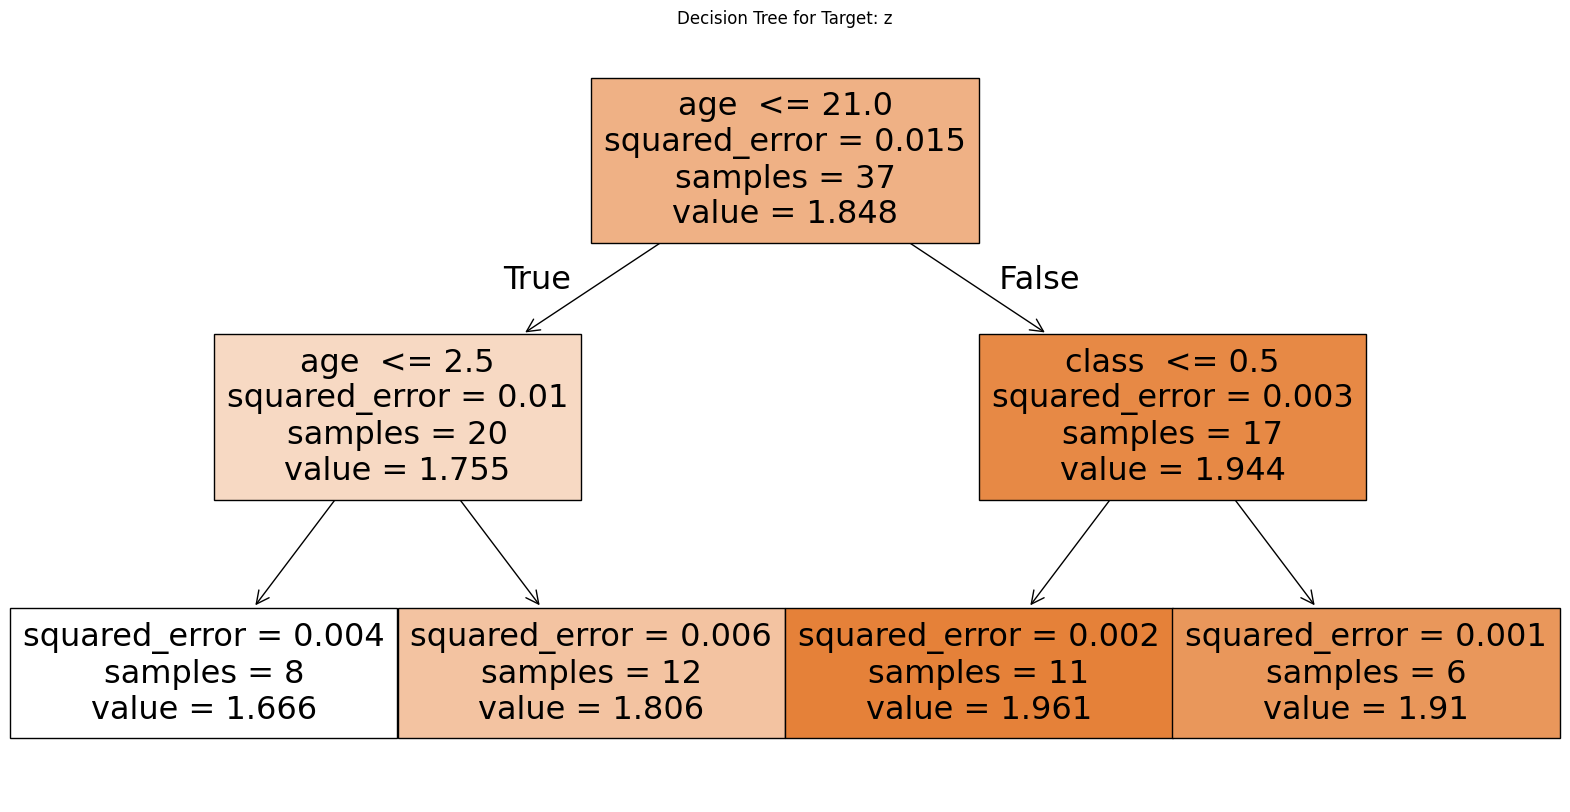

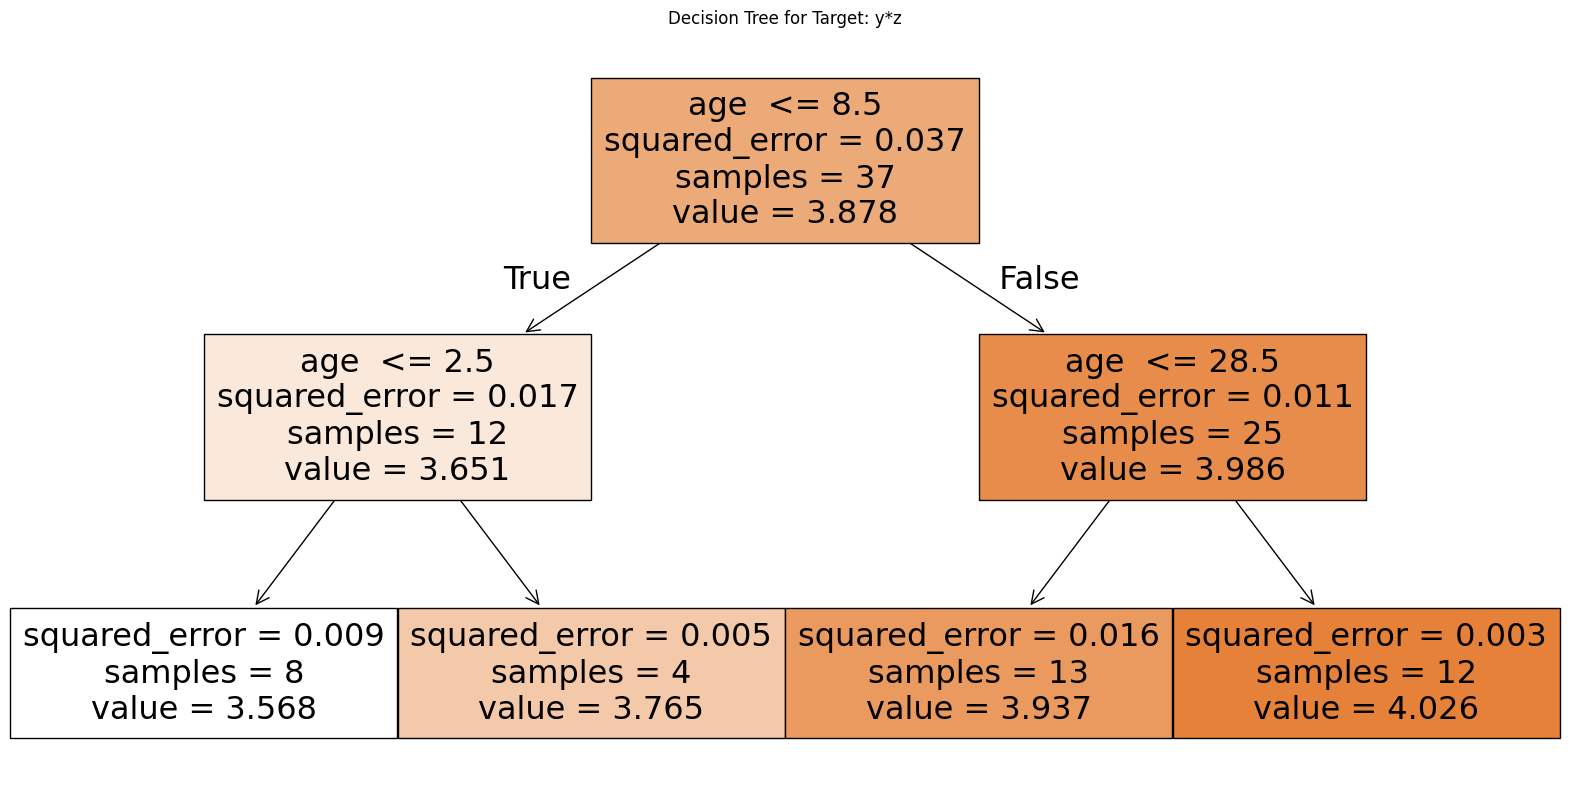

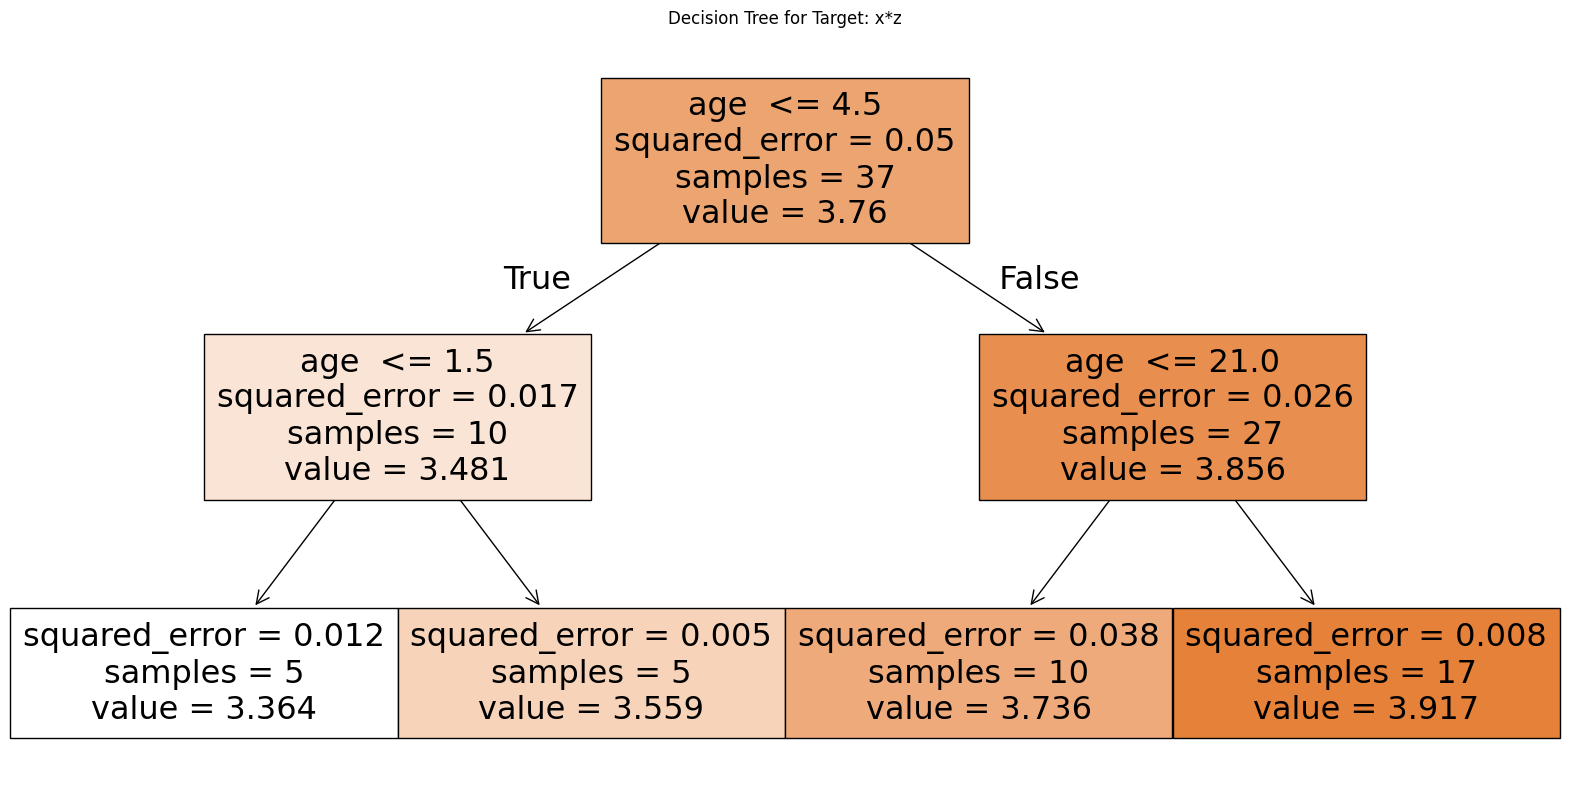

In [66]:

from sklearn.tree import plot_tree
# أسماء الأهداف حسب ترتيب الأعمدة
target_names = ['z', 'y*z', 'x*z']

# رسم أول شجرة من كل نموذج فرعي
for i, name in enumerate(target_names):
    # أخذ أول شجرة من كل RandomForest خاص بكل هدف
    tree = model.estimators_[i].estimators_[4]

    plt.figure(figsize=(20, 10))
    plot_tree(tree, feature_names=X_train.columns, filled=True)
    plt.title(f"Decision Tree for Target: {name}")
    plt.show()

In [232]:
y_pred[0,1].size

1

In [181]:
pre = pd.DataFrame(y_pred , columns=['x_pre','zy_pre','zx_pre'])
y_test=10**y_test

In [80]:
y_test = y_test.reset_index(drop=True)
pre = pre.reset_index(drop=True)
y_test.columns = ['Actual_z', 'Actual_zy', 'Actual_zx']
pre.columns = ['Predicted_z', 'Predicted_zy', 'Predicted_zx']

# دمج الأعمدة جنبًا إلى جنب
model_eval = pd.concat([y_test, pre], axis=1)

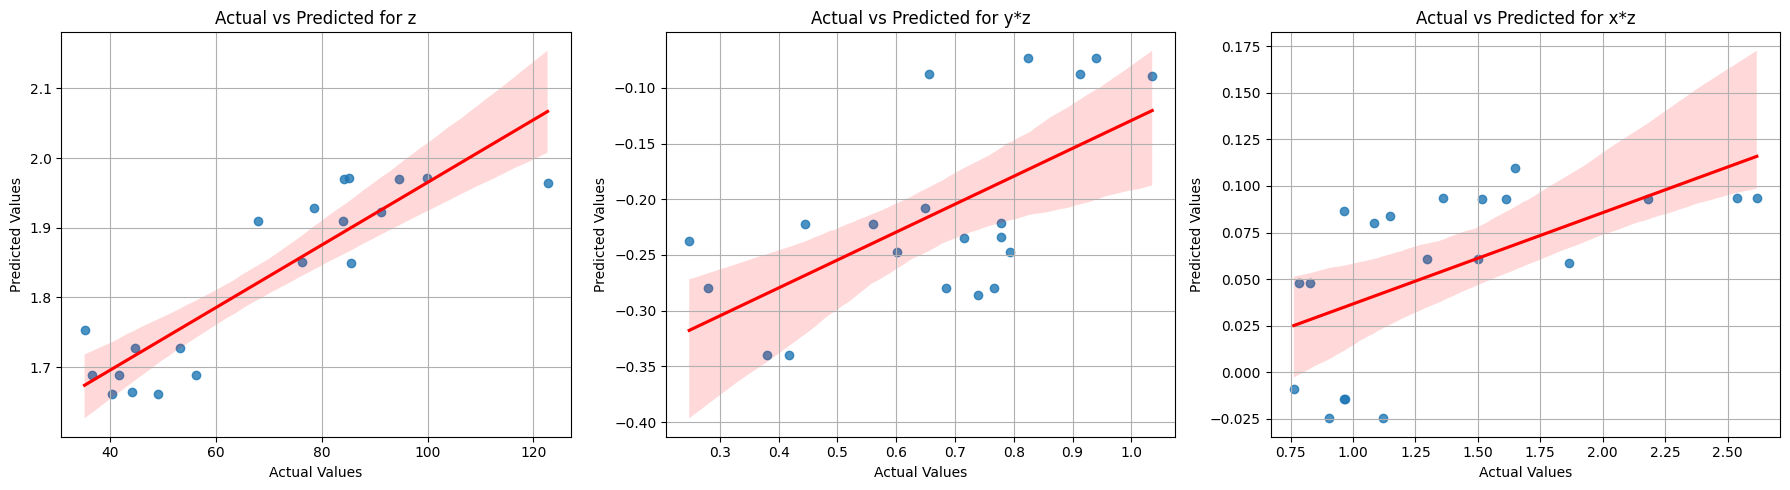

In [83]:
import matplotlib.pyplot as plt
import seaborn as sns

# توقعات الموديل
y_pred = model.predict(X_test)

# أسماء الأعمدة (targets)
target_names = ['z', 'y*z', 'x*z']

# رسم لكل Target على حدة
plt.figure(figsize=(18, 5))
for i, target in enumerate(target_names):
    plt.subplot(1, 3, i + 1)
    sns.regplot(x=y_test.iloc[:, i].values, y=y_pred[:, i], line_kws={"color": "red"})
    plt.title(f'Actual vs Predicted for {target}')
    plt.xlabel('Actual Values')
    plt.ylabel('Predicted Values')
    plt.grid(True)

plt.tight_layout()
plt.show()

